# Project: Investigate a Dataset - Medical Appointment No-Show Analysis

## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
<li><a href="#conclusions">Conclusions</a></li>
</ul>

<a id='intro'></a>
## Introduction

This project analyzes a dataset containing information about more than 100,000 medical appointments in Brazil. The goal is to identify factors that may be related to whether a patient attends or misses a scheduled appointment.

The analysis will focus on the following research questions:

1. Does the amount of time between scheduling and the appointment affect whether patients miss their appointments?
2. Does receiving an SMS reminder affect whether patients attend their appointments?

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Display plots directly in the notebook
%matplotlib inline

# Load the medical appointment dataset into a pandas DataFrame
df= pd.read_csv('noshowappointments-kagglev2-may-2016.csv')


<a id='wrangling'></a>
## Data Wrangling

### General Properties


In [26]:
# Load the dataset into a pandas DataFrame
df = pd.read_csv('noshowappointments-kagglev2-may-2016.csv')

# Display the first five rows of the ds
df.head()

# View the number of rows and columns
df.shape

# Display the column names, data types and missing values
df.info()

# Generate summary statistics for the numerical columns
df.describe()

# Check for missing values in each column
df.isnull().sum()

# Check for duplicate rows in the ds
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


0

In [39]:
# Convert the ScheduledDay column to datetime format
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])

# Convert the AppointmentDay column to datetime format
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

In [40]:
df['WaitDays'] = (
    df['AppointmentDay'].dt.normalize()
    - df['ScheduledDay'].dt.normalize()
).dt.days

df[['ScheduledDay', 'AppointmentDay', 'WaitDays']].head()

,ScheduledDay,AppointmentDay,WaitDays
0,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,0
1,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,0
2,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,0
3,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,0
4,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,0


### Distribution of Appointment Wait Times

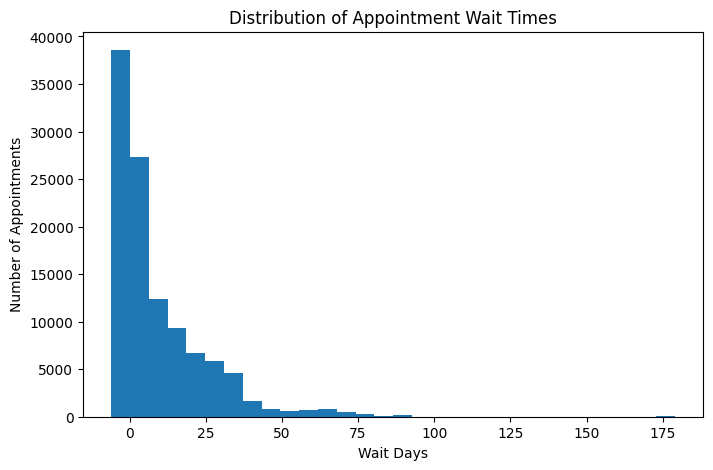

In [41]:
# Display the distribution of appointment wait times

plt.figure(figsize=(8,5))
plt.hist(df['WaitDays'], bins=30)

plt.title('Distribution of Appointment Wait Times')
plt.xlabel('Wait Days')
plt.ylabel('Number of Appointments')
plt.show()

The histogram shows that most appointments had short wait times. The distribution is right-skewed because relatively few appointments had much longer wait times.

In [45]:
# Remove appts with invalid negative wait times
df = df[df['WaitDays'] >= 0]

# Verify that the min wait time is now 0 days
df['WaitDays'].min()

0

### Data Cleaning Summary

The dataset was examined for missing values and duplicate records. No missing values or duplicate rows were identified.

The 'ScheduledDay' and 'AppointmentDay' columns were converted to datetime format. A new variable named 'WaitDays' was created to represent the number of days between scheduling and the appointment. Records with negative wait times were removed before analysis.

### Research Question 1: Does Wait Time Affect Appointment Attendance?

Does the number of days between scheduling an appointment and the appointment date affect whether patients attend their scheduled appointment?

To answer this question, the analysis compares the `WaitDays` variable with the `No-show` outcome to determine whether longer wait times are associated with a higher rate of missed appointments.

In [20]:
# Create a reusable function for bar charts

def plot_bar(data, title, xlabel, ylabel):
    data.plot(kind='bar', figsize=(8,5))
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=0)
    plt.show()

No-show
No      8.754659
Yes    15.835484
Name: WaitDays, dtype: float64


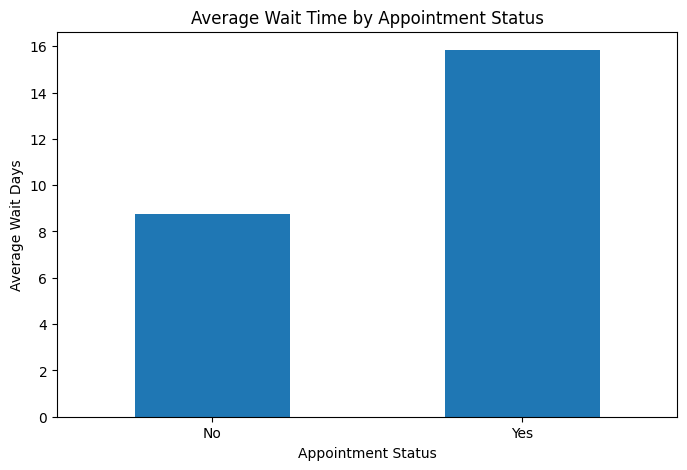

In [22]:
# Calculate the average wait time for patients who attended and missed appointments

wait_by_status = df.groupby('No-show')['WaitDays'].mean()

print(wait_by_status)

plot_bar(
    wait_by_status,
    'Average Wait Time by Appointment Status',
    'Appointment Status',
    'Average Wait Days'
)



### Interpretation

The average wait time differs between patients who attended their appointments and those who did not.

Patients with longer wait times tended to miss their appointments more often than patients with shorter wait times. 

This finding suggests that the amount of time between scheduling and the appointment is associated with appointment attendance. 

Since this is an observational dataset, the analysis cannot determine that longer wait times directly caused patients to miss their appointments.

### Research Question 2

Does receiving an SMS reminder appear to be associated with appointment attendance?

To answer this question, the analysis compares the `SMS_received` variable with the `No-show` outcome to determine whether appointment reminders are associated with attendance.

No-show          No    Yes
SMS_received              
0             83.30  16.70
1             72.43  27.57


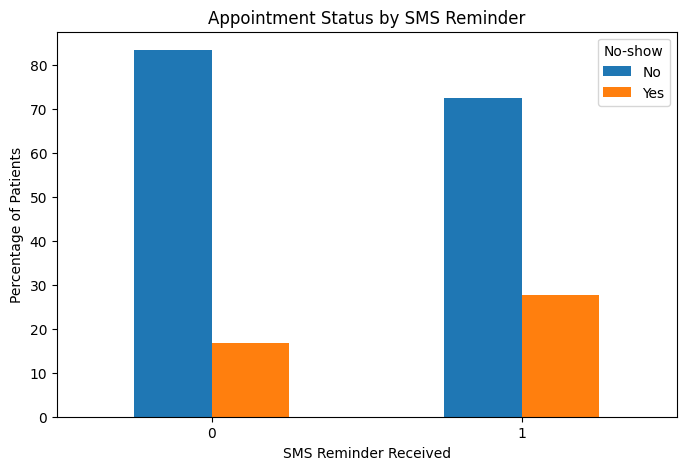

In [30]:
# Calculate the % of appt outcomes for each SMS group
sms_results = pd.crosstab(
        df['SMS_received'],
    df['No-show'],
    normalize='index'
) * 100

# Round the percentages using NumPy
sms_results = np.round(sms_results, 2)

print(sms_results)

# Plot the SMS results using the reusable bar-chart function
plot_bar(
    sms_results,
    'Appointment Status by SMS Reminder',
    'SMS Reminder Received',
    'Percentage of Patients'
)

### Interpretation

Patients who did not receive an SMS reminder had 62,510 completed appointments and 12,530 missed appointments. 

Patients who received an SMS reminder had 25,698 completed appointments and 9,784 missed appointments. 

These results show a difference in attendance between the two groups and the comparison identifies an association between SMS reminders and appointment attendance.

It is important to note that this does not demonstrate the receiving an SMS reminder caused the difference because other factors may also influence whether a patient attends an appointment.

### Research Question 3

Does patient age appear to be associated with appointment attendance?

No-show
No     37.790064
Yes    34.317667
Name: Age, dtype: float64


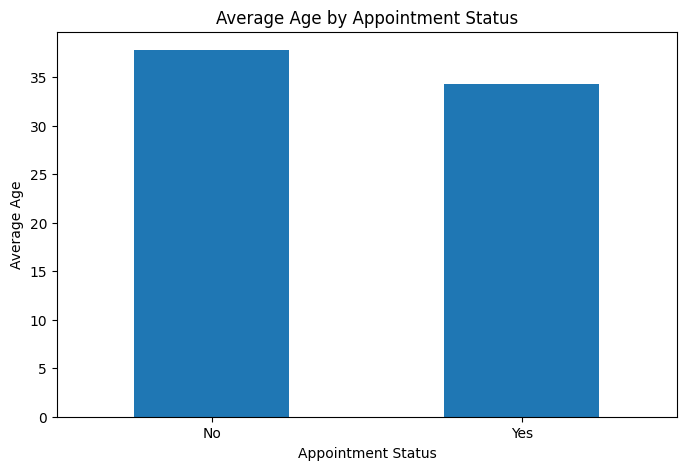

In [44]:
# Calculate the avg age for patients who attended and missed appts

age_by_status = df.groupby('No-show')['Age'].mean()

print(age_by_status)

# Display the avg age by appintment status
plot_bar(
    age_by_status,
    'Average Age by Appointment Status',
    'Appointment Status',
    'Average Age'
)

### Interpretation 

Patients who attended their appointments were older on average than patients who missed their appointments. The average age of patients who attended was approximately 38 years, compared with about 34 years for patients who did not attend. 

This suggests that age may be associated with appointment attendance. This analysis identifies a relationship in the dataset but does not show that age directly affects attendance.

<a id='conclusions'></a>
## Conclusions

This analysis examined several factors that may be associated with appointment attendance. The results showed that patients who missed their appintments had longer average wait time than patients who  attended. The SMS reminder analysis showed differences in attendance rates between patients who received reminders and those who did not. The analysis also found that patients who attended their appointments were slightly older on average than patients who missed their appointments. 

These findings suggest that wait time, SMS reminders, and patient age may each be associated with appointment attendance. Since the dataset is observational the analysis cannot determine cause-and-effect relationships. Other factors included in the dataset may also influence whether patients attended their appointments.


In [26]:
# Running this cell will execute a bash command to convert this notebook to an .html file
!python -m nbconvert --to html Investigate_a_Dataset.ipynb

[NbConvertApp] Converting notebook Investigate_a_Dataset.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 354652 bytes to Investigate_a_Dataset.html
